<a href="https://colab.research.google.com/github/Mega-Gangar/Data-Analytics-mini-project/blob/main/analysis_ipynbz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [189]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [190]:
#Load the Amazon_Sales.xlsx dataset
df=pd.read_excel('/content/amazon.xlsx')

In [191]:
df.head()

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411


In [192]:
df.shape

(100000, 20)

In [193]:
df.columns.tolist()

['OrderID',
 'OrderDate',
 'CustomerID',
 'CustomerName',
 'ProductID',
 'ProductName',
 'Category',
 'Brand',
 'Quantity',
 'UnitPrice',
 'Discount',
 'Tax',
 'ShippingCost',
 'TotalAmount',
 'PaymentMethod',
 'OrderStatus',
 'City',
 'State',
 'Country',
 'SellerID']

In [194]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   OrderID        100000 non-null  object        
 1   OrderDate      100000 non-null  datetime64[ns]
 2   CustomerID     100000 non-null  object        
 3   CustomerName   100000 non-null  object        
 4   ProductID      100000 non-null  object        
 5   ProductName    100000 non-null  object        
 6   Category       100000 non-null  object        
 7   Brand          100000 non-null  object        
 8   Quantity       100000 non-null  int64         
 9   UnitPrice      100000 non-null  float64       
 10  Discount       100000 non-null  float64       
 11  Tax            100000 non-null  float64       
 12  ShippingCost   100000 non-null  float64       
 13  TotalAmount    100000 non-null  float64       
 14  PaymentMethod  100000 non-null  object        
 15  O

In [195]:
df.describe()

,OrderDate,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount
count,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,2022-06-30 23:55:49.440000,3.001400,302.905748,0.074226,68.468902,7.406660,918.256479
min,2020-01-01 00:00:00,1.000000,5.000000,0.000000,0.000000,0.000000,4.270000
25%,2021-04-01 00:00:00,2.000000,154.190000,0.000000,15.920000,3.680000,340.890000
50%,2022-07-01 00:00:00,3.000000,303.070000,0.050000,45.250000,7.300000,714.315000
75%,2023-09-29 00:00:00,4.000000,451.500000,0.100000,96.060000,11.150000,1349.765000
max,2024-12-29 00:00:00,5.000000,599.990000,0.300000,538.460000,15.000000,3534.980000
std,NaN,1.413548,171.840797,0.082583,74.131180,4.324057,724.508332


In [196]:
#Filtering "Delivered" Order Status from the dataset
df_valid=df[df['OrderStatus']!="Cancelled"]
df_valid.head()

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
5,ORD0000006,2022-12-31,CUST042705,Karan Sharma,P00023,Cookware Set,Books,ReadMore,4,449.73,0.00,215.87,2.74,2017.53,UPI,Delivered,Los Angeles,CA,United States,SELL01494


In [197]:
#KPI Analysis
#	Total Sales
total_sales=df_valid['TotalAmount'].sum()
print(f'Total Sales: {total_sales}')

Total Sales: 88974525.53


In [198]:
#	Total Orders
total_orders=df_valid['OrderID'].count()
print(f'Total Orders: {total_orders}')

Total Orders: 96972


In [199]:
# Average Sales
avg_sales=df_valid['TotalAmount'].mean()
print(f'Average Sales: {avg_sales}')

Average Sales: 917.5280032380481


In [200]:
# Maximum sale
max_sales=df_valid['TotalAmount'].max()
print(f'Maximum Sales: {max_sales}')

Maximum Sales: 3534.98


In [201]:
# Minimum sale
min_sales=df_valid['TotalAmount'].min()
print(f'Minimum Sales: {min_sales}')

Minimum Sales: 4.27


In [202]:
#Sales Analysis
#Total Sales by State(Top 10)
df_valid.groupby('State')['TotalAmount'].sum().rename('Total_Sales').sort_values(ascending=False).head(10)

,Total_Sales
State,
TX,22167953.84
CA,17709938.13
NC,4610387.72
WA,4531441.11
PA,4504755.81
IL,4504123.30
CO,4477183.14
OH,4470287.90
FL,4452627.45


In [203]:
#City-wise Sales
df.groupby('City')['TotalAmount'].sum().rename('Total_Sales').sort_values(ascending=False)

,Total_Sales
City,
Charlotte,4747701.73
Dallas,4730108.67
San Jose,4669614.33
Seattle,4660962.17
Philadelphia,4650673.88
Denver,4638498.97
Austin,4638403.18
Chicago,4632847.44
Los Angeles,4620629.78


In [204]:
#Country-wise Sales
df.groupby('Country')['TotalAmount'].sum().rename('Total_Sales').sort_values(ascending=False)

,Total_Sales
Country,
United States,64310048.50
India,13875839.12
Canada,5323757.00
United Kingdom,4526896.86
Australia,3789106.44


In [205]:
#Total Sales by Category (Top 10)
df_valid.groupby('Category')['TotalAmount'].sum().rename('Total_Sales').sort_values(ascending=False).head(10)

,Total_Sales
Category,
Electronics,15084124.52
Sports & Outdoors,14872709.95
Clothing,14817297.02
Books,14798581.02
Toys & Games,14717174.83
Home & Kitchen,14684638.19


In [206]:
#Brand Performance Analysis
df_valid.groupby('Brand')['TotalAmount'].sum().rename('Total_Sales').sort_values(ascending=False)

,Total_Sales
Brand,
KiddoFun,9043817.16
CoreTech,9020527.53
ReadMore,9003938.38
UrbanStyle,8982543.73
Zenith,8951485.90
Apex,8863146.16
FitLife,8793368.61
NexPro,8779353.29
HomeEase,8775284.30


In [207]:
#Total Quantity
df.groupby('ProductName')['Quantity'].sum().sort_values(ascending=False)

,Quantity
ProductName,
LED Desk Lamp,6344
Water Bottle,6275
Memory Card 128GB,6240
Router,6202
Board Game,6200
Microphone,6196
Gaming Mouse,6170
Electric Kettle,6165
Mechanical Keyboard,6161


In [208]:
#Top 10 products sold by quantity
df_valid.groupby('ProductName')['Quantity'].sum().sort_values(ascending=False).head(10)

,Quantity
ProductName,
LED Desk Lamp,6171
Water Bottle,6060
Memory Card 128GB,6030
Router,6016
Board Game,6010
Microphone,5991
Electric Kettle,5956
Mechanical Keyboard,5955
Smart Light Bulb,5947


In [209]:
#Top 10 expensive products sold by Unit Price
df.groupby('ProductName')['UnitPrice'].mean().sort_values(ascending=False).head(10)

,UnitPrice
ProductName,
Smartwatch,312.787526
Dress Shirt,312.308919
Bluetooth Speaker,310.940868
Phone Tripod,309.047886
Memory Card 128GB,307.712050
Children's Book,307.312179
Smartphone Case,307.154077
Mechanical Keyboard,306.598461
Fitness Band,306.202105


In [210]:
#Total Orders done by Payment Method(Delivered)
df_valid['PaymentMethod'].value_counts()

,count
PaymentMethod,
Credit Card,33955
Debit Card,19431
UPI,14622
Amazon Pay,14556
Net Banking,9636
Cash on Delivery,4772


In [211]:
#Total Orders done by Payment Method(Total)
df['PaymentMethod'].value_counts()

,count
PaymentMethod,
Credit Card,35038
Debit Card,20024
UPI,15066
Amazon Pay,15017
Net Banking,9927
Cash on Delivery,4928


In [212]:
#Percentage of Cancelled Orders by Payment Orders
total = df['PaymentMethod'].value_counts()
delivered = df_valid['PaymentMethod'].value_counts()
cancel_percentage = ((total - delivered.reindex(total.index, fill_value=0)) / total) * 100
print(cancel_percentage.round(2))

PaymentMethod
Credit Card         3.09
Debit Card          2.96
UPI                 2.95
Amazon Pay          3.07
Net Banking         2.93
Cash on Delivery    3.17
Name: count, dtype: float64


In [213]:
#Seller Performance
#Top 10 Sellers by Total Sales
df_valid.groupby('SellerID')['TotalAmount'].sum().sort_values(ascending=False).head(10)

,TotalAmount
SellerID,
SELL00806,69605.10
SELL00536,69248.00
SELL00709,68583.20
SELL01922,68290.28
SELL01584,67749.95
SELL01225,67530.78
SELL00221,67512.01
SELL00371,67467.07
SELL01122,67362.92


In [214]:
#Top 5 Customers based on total sales.
df_valid.groupby(
    ['CustomerID','CustomerName'])['TotalAmount'].sum().sort_values(ascending=False).head(5)

,,TotalAmount
CustomerID,CustomerName,
CUST010696,Pooja Patel,5436.04
CUST035973,Neha Sharma,5124.43
CUST009614,Vikas Mehta,5003.65
CUST018720,Arjun Kapoor,4773.18
CUST022824,Pooja Joshi,4755.48


In [215]:
#Monthly sales trend using the Order Date column.
df_valid['OrderDate']=pd.to_datetime(df_valid['OrderDate'])
monthly_sales = df_valid.groupby(df_valid['OrderDate'].dt.to_period('M'))['TotalAmount'].sum()
print(monthly_sales)

OrderDate
2020-01    1581686.94
2020-02    1306693.36
2020-03    1533391.27
2020-04    1544906.16
2020-05    1496363.49
2020-06    1470775.54
2020-07    1508463.43
2020-08    1592602.08
2020-09    1502002.98
2020-10    1456483.70
2020-11    1461353.71
2020-12    1529479.20
2021-01    1517682.35
2021-02    1382996.59
2021-03    1426339.47
2021-04    1412748.97
2021-05    1514581.31
2021-06    1552417.48
2021-07    1542777.20
2021-08    1501672.40
2021-09    1498580.41
2021-10    1466382.51
2021-11    1370223.82
2021-12    1469237.23
2022-01    1558296.34
2022-02    1327605.46
2022-03    1529080.32
2022-04    1466947.52
2022-05    1479676.41
2022-06    1482622.64
2022-07    1524781.64
2022-08    1470020.33
2022-09    1410417.97
2022-10    1485407.57
2022-11    1476945.52
2022-12    1556107.47
2023-01    1529031.33
2023-02    1343409.08
2023-03    1513005.17
2023-04    1525211.16
2023-05    1549512.39
2023-06    1437972.02
2023-07    1520892.81
2023-08    1534882.89
2023-09    1492319.47


/tmp/ipykernel_1483/574075573.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_valid['OrderDate']=pd.to_datetime(df_valid['OrderDate'])


In [216]:
#Sales generated by each State for every Category.
df_valid.groupby(['State','Category'])['TotalAmount'].sum().rename('Total_Sales').sort_values(ascending=False).head(10)

State  Category         
TX     Clothing             3776176.80
       Sports & Outdoors    3748561.39
       Electronics          3718728.48
       Books                3683817.84
       Home & Kitchen       3648259.21
       Toys & Games         3592410.12
CA     Toys & Games         2999964.11
       Electronics          2995753.66
       Sports & Outdoors    2987488.57
       Books                2944416.98
Name: Total_Sales, dtype: float64

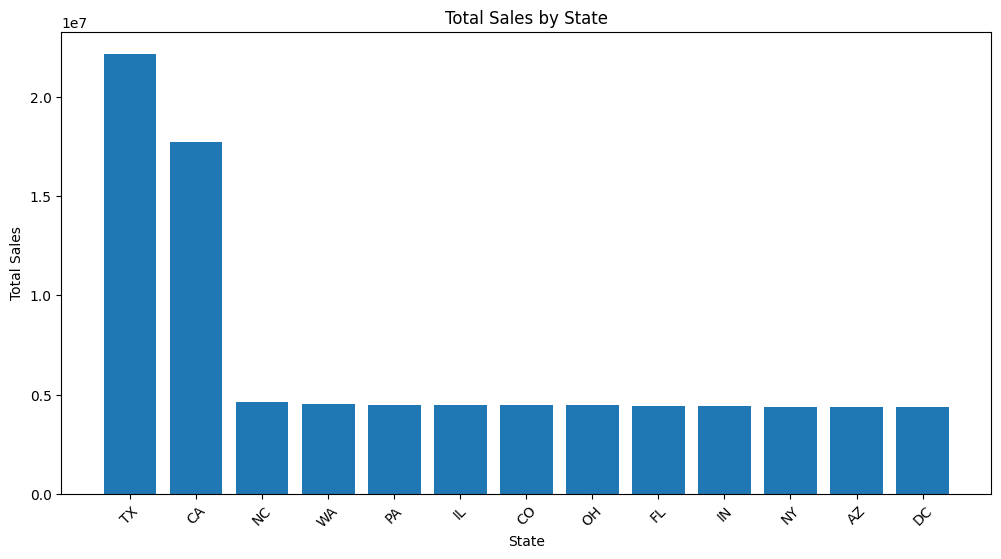

In [217]:
#Bar Chart (Sales by State)
sales=df_valid.groupby('State')['TotalAmount'].sum().sort_values(ascending=False)
plt.figure(figsize=(12,6))
plt.bar(sales.index,sales.values)
plt.xlabel('State')
plt.xticks(rotation=45)
plt.ylabel('Total Sales')
plt.title('Total Sales by State')
plt.show()

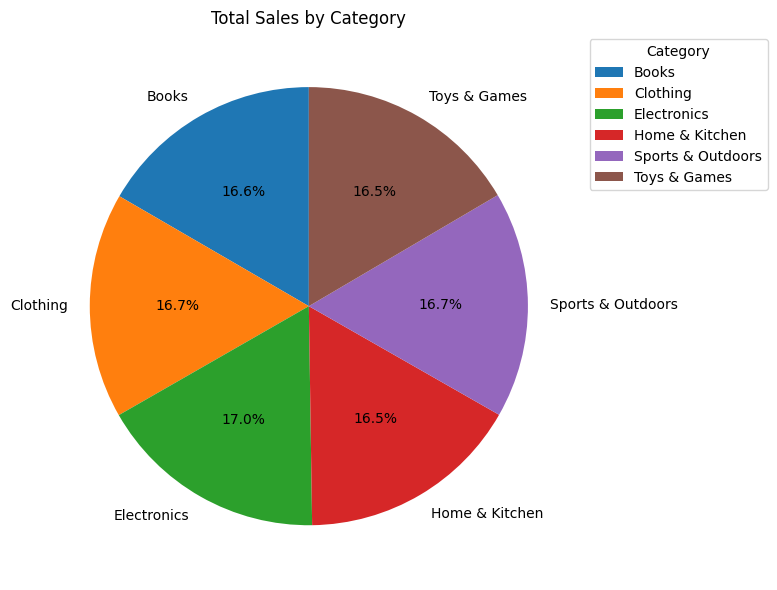

In [218]:
#Pie Chart (Category-wise Sales)
plt.figure(figsize=(8,6))
df_valid.groupby('Category')['TotalAmount'].sum().plot(kind='pie',autopct='%.1f%%',startangle=90)
plt.xlabel('')
plt.ylabel('')
plt.title('Total Sales by Category')
plt.legend(title="Category", loc='best',bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()

/tmp/ipykernel_1483/1193126462.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_valid['OrderDate']=pd.to_datetime(df_valid['OrderDate'])


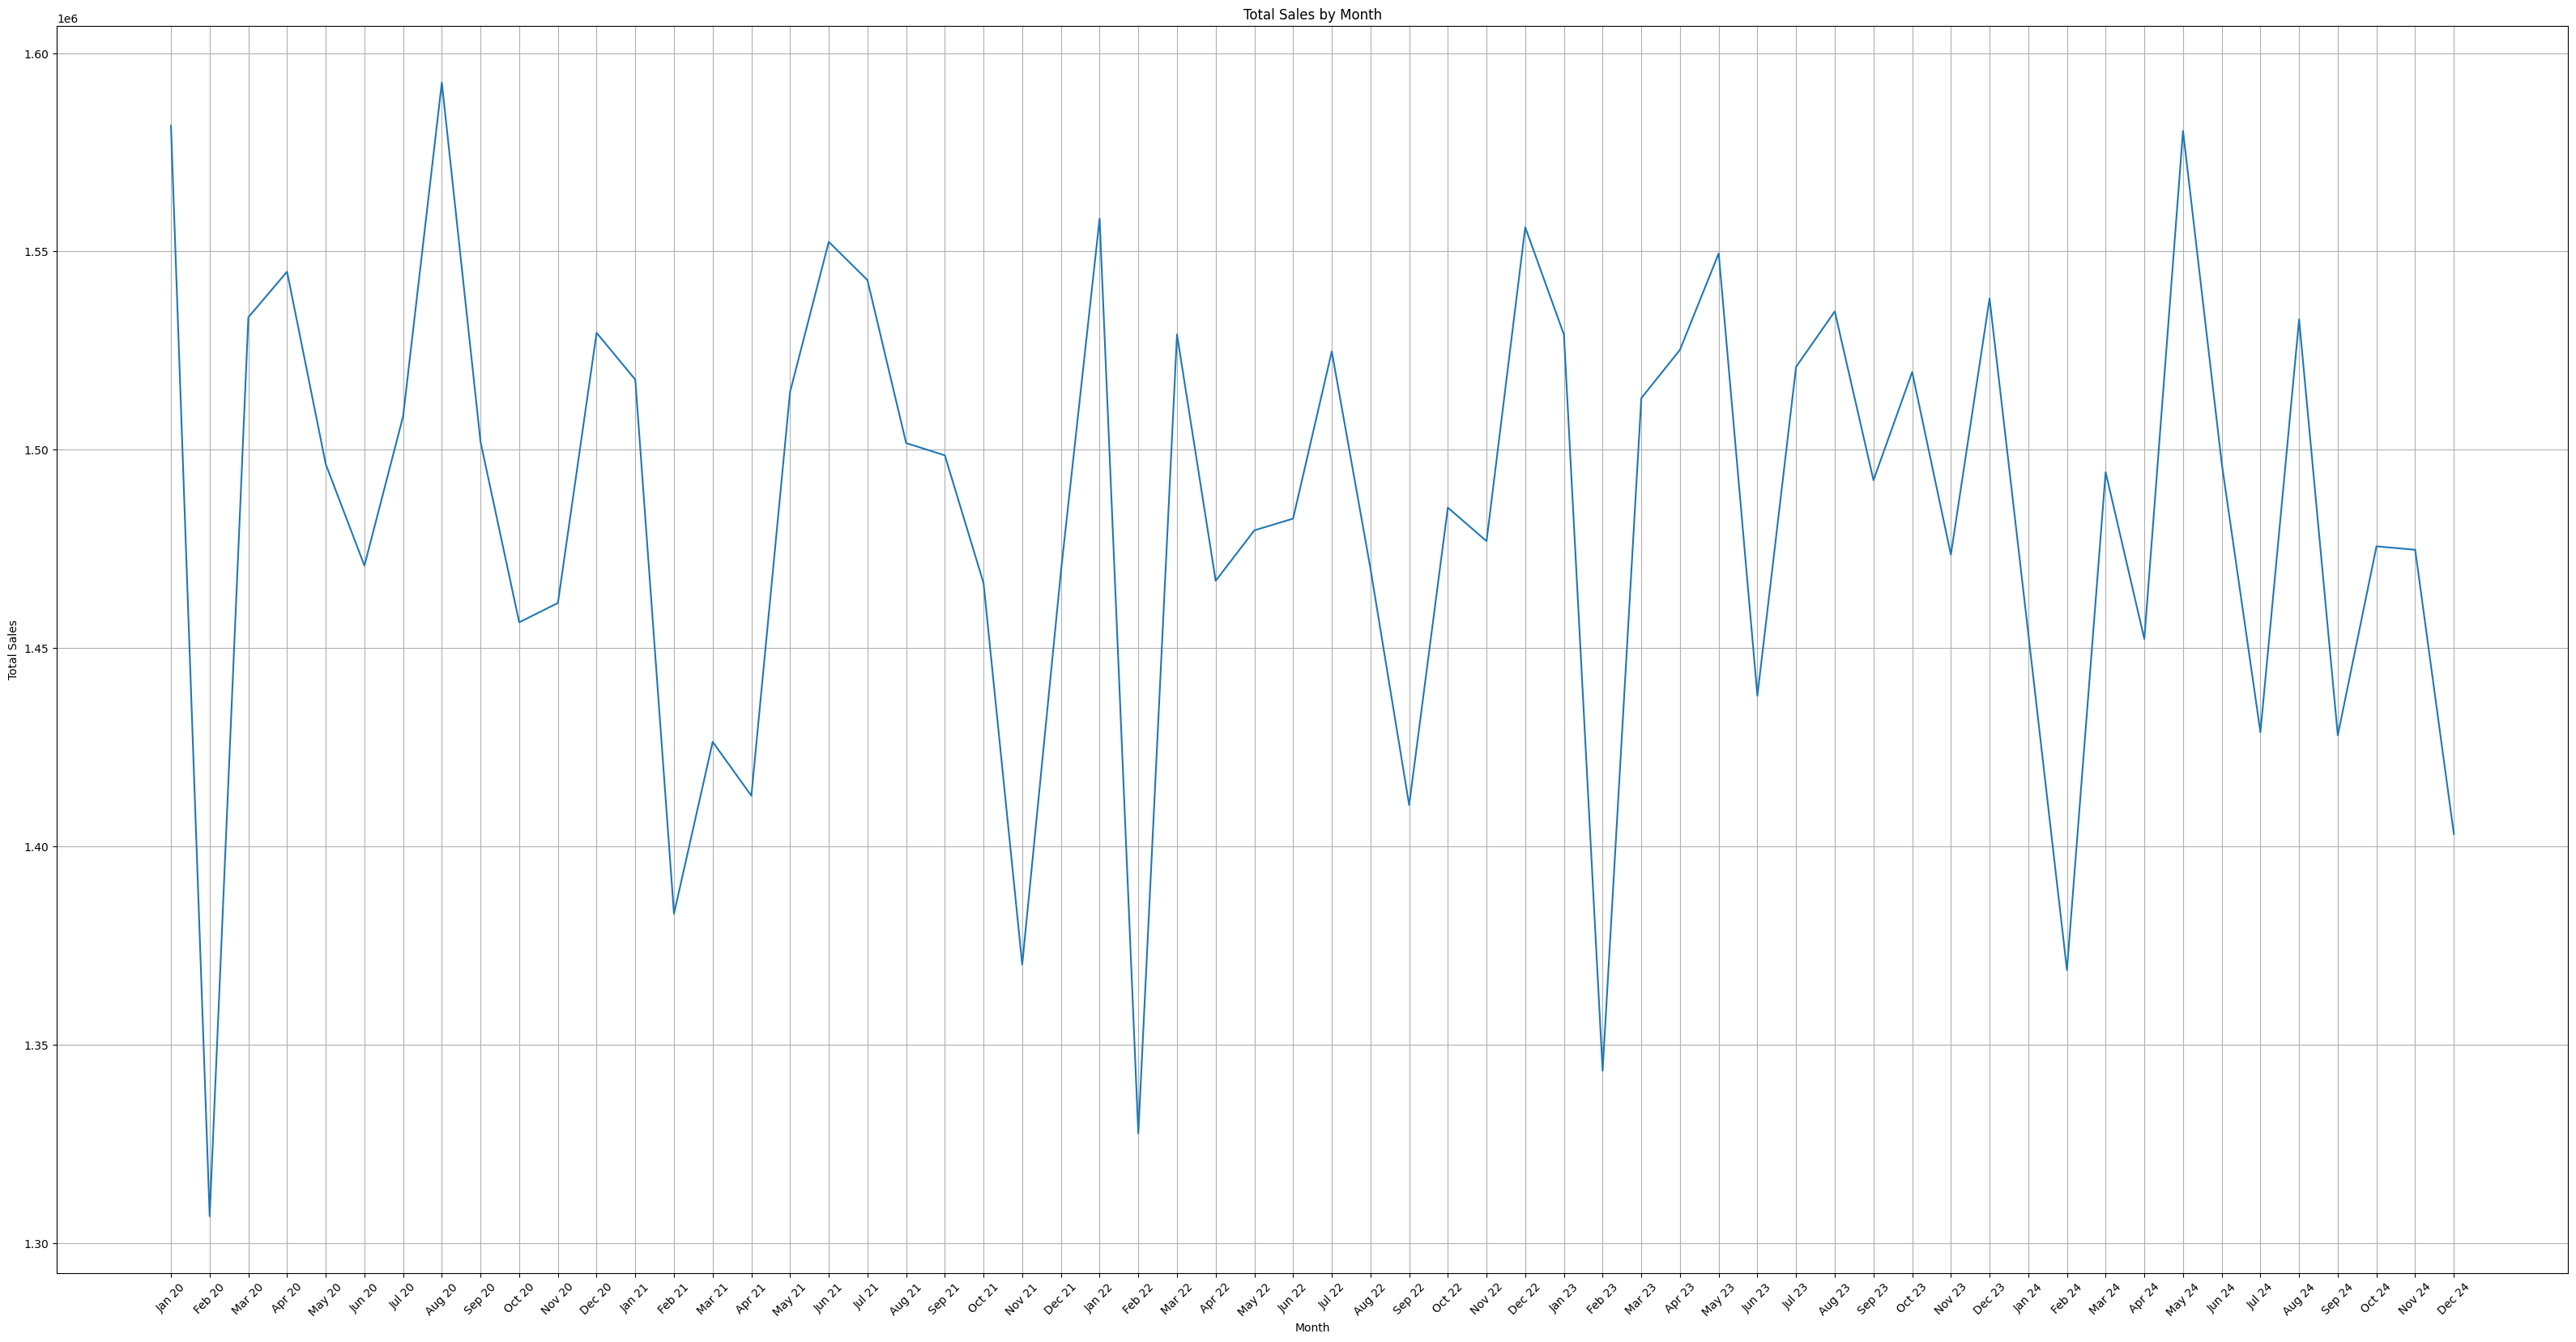

In [219]:
#Line Chart showing Monthly Sales Trend.
df_valid['OrderDate']=pd.to_datetime(df_valid['OrderDate'])
monthly_sales = df_valid.groupby(df_valid['OrderDate'].dt.to_period('M'))['TotalAmount'].sum()
months = monthly_sales.index.strftime('%b %y')
plt.figure(figsize=(40,20))
plt.plot(months,monthly_sales.values)
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.grid(True)
plt.ylabel('Total Sales')
plt.title('Total Sales by Month')
plt.show()

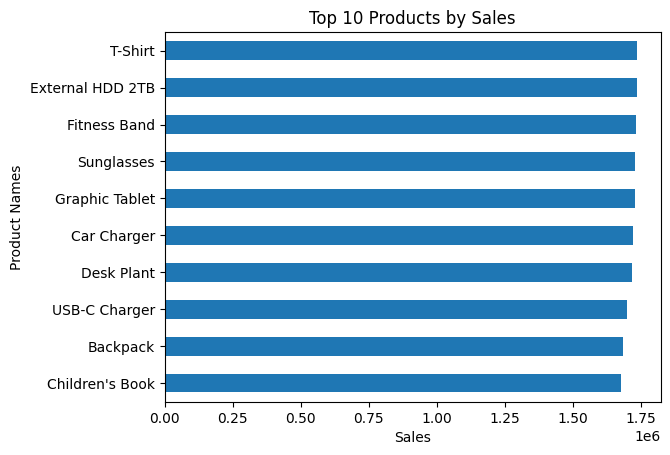

In [220]:
#Q18. Create a Horizontal Bar Chart showing the Top 10 Products by Sales.
df_valid.groupby('ProductName')['TotalAmount'].sum().sort_values().head(10).plot(kind='barh')
plt.xlabel('Sales')
plt.ylabel('Product Names')
plt.title('Top 10 Products by Sales')
plt.show()

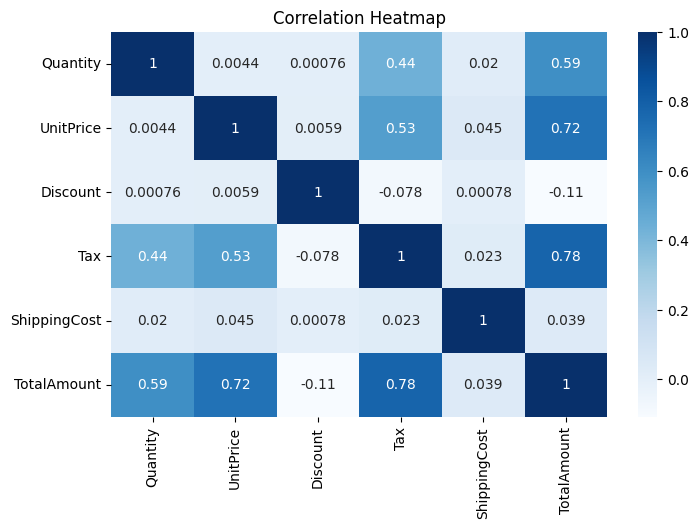

In [221]:
#Correlation between Dependent and Independent variables
corr_data=df_valid[['Quantity',
 'UnitPrice',
 'Discount',
 'Tax',
 'ShippingCost',
 'TotalAmount']].corr()
plt.figure(figsize=(8,5))
sns.heatmap(corr_data,annot=True,cmap='Blues')
plt.title('Correlation Heatmap')
plt.show()

In [225]:
#Performance Analysis of Linear Regression Model Using R² and RMSE
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score

features=['Quantity',
 'UnitPrice',
 'Discount',
 'Tax',
 'ShippingCost',
 ]
X=df_valid[features]
y=df_valid['TotalAmount']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
rmse=root_mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print(f'Root Mean Squared Error: {rmse:.2f}')
print(f'R-squared:{r2:.2f}')

Root Mean Squared Error: 217.45
R-squared:0.91


# **Business Insights**
1.   **Focus on High-Revenue States**
      *   Increase inventory
      *   Launch regional offers in low-performing States
      *   For example: States like *TX,CA,NC*
2.   **Boost High-Demand Products**
      *   Maintain *High-Demand Products* stocks
      *   Promote them on *HomePage*
      *   For example: Products like *LED Desk Lamp*, *Water Bottle*
*Memory Card 128GB*
3.    **Optimize Payment Methods**
      *   Promote most-used payment methods *(like Credit Card, Debit Card)*
      *   Reduce friction in checkout so that payment methods like *Cash on Delivery* shifts to most-used payment methods
4.    **Performance Analysis of Linear Regression Model Using R² and RMSE**
      *   **Independent Variable:** *Quantity, UnitPrice, Discount, Tax, ShippingCost*
      *   **Dependent Variables:** *TotalAmount*
      *   **Concludion:**
          * **91%** *of the data,* predicts TotalAmount quite accurately.
          * The *average error* is around **217 units**.

